In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
print("Files and folders here:")

for item in os.listdir():
    print(item)

Files and folders here:
.agents
.aitk
.anaconda
.android
.azure
.cache
.codex
.conda
.condarc
.continuum
.copilot
.gitconfig
.ipynb_checkpoints
.ipython
.jupyter
.keras
.lesshst
.matplotlib
.MemuHyperv
.sbx-denybin
.spyder-py3
.streamlit
.vscode
.vscode-shared
.~Untitled.ipynb
0.26.0
0.26.0'
adv_stat
air_drawn.ipynb
ANN
AppData
Application Data
Contacts
Cookies
Doc
Downloads
EDA
Favorites
gensim-data
Hand_Gesture_ANN.ipynb
igct
IPL
Lib
Links
Local Settings
Machine Learning
ML
models
Music
My Documents
NetHood
NLP
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{291ec652-ef9a-11ef-8a65-ca264212e6d7}.TM.blf
NTUSER.DAT{291ec652-ef9a-11ef-8a65-ca264212e6d7}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{291ec652-ef9a-11ef-8a65-ca264212e6d7}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
Pictures
PrintHood
Recent
results
Retail-Analysis-Project
Saved Games
Searches
SendTo
senti.csv
sql
Start Menu
tcs
Templates
train_model.py
Untitled.ipynb
Untitled1.ipynb
Video

In [3]:
dataset_path = r"C:\Users\pujit\OneDrive\Desktop\project3\dataset"

print("Dataset path:", dataset_path)
print("Exists:", os.path.exists(dataset_path))

Dataset path: C:\Users\pujit\OneDrive\Desktop\project3\dataset
Exists: True


In [4]:
class_names = sorted(
    [
        folder
        for folder in os.listdir(dataset_path)
        if folder.isdigit()
    ],
    key=int
)

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Number of classes: 10


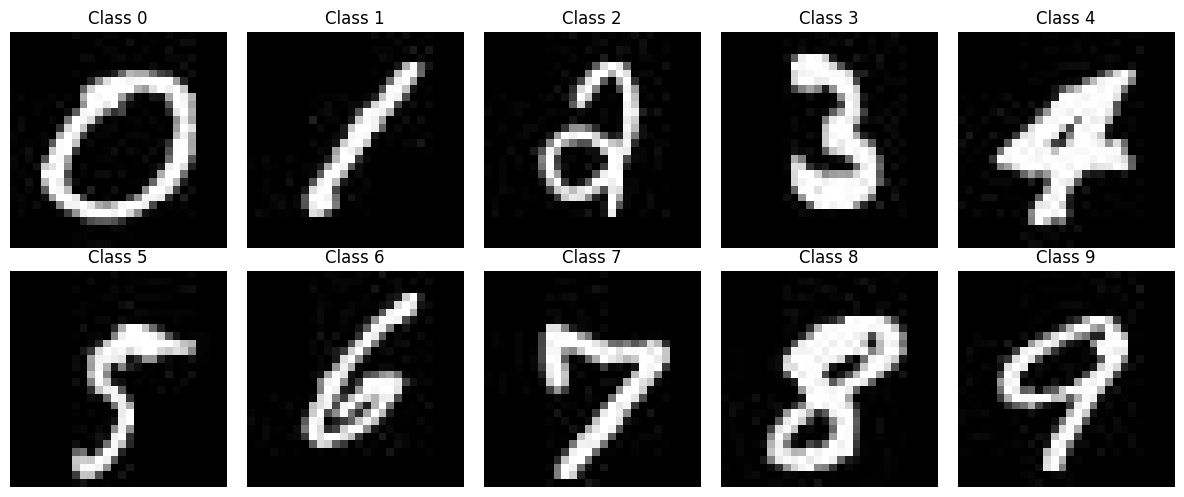

In [5]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5)
)

axes = axes.ravel()

for digit in range(10):

    class_path = os.path.join(
        dataset_path,
        str(digit)
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp", ".webp")
        )
    ]

    image_path = os.path.join(
        class_path,
        files[0]
    )

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    axes[digit].imshow(
        image,
        cmap="gray"
    )

    axes[digit].set_title(
        f"Class {digit}"
    )

    axes[digit].axis("off")

plt.tight_layout()
plt.show()

In [6]:
class_counts = {}

for digit in range(10):

    class_path = os.path.join(
        dataset_path,
        str(digit)
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp", ".webp")
        )
    ]

    class_counts[digit] = len(files)

print("Class Distribution:")
print(pd.Series(class_counts).sort_index())

Class Distribution:
0    2417
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
dtype: int64


In [7]:
MIN_PER_CLASS = min(class_counts.values())

print("Images per class:", MIN_PER_CLASS)
print("Total balanced images:", MIN_PER_CLASS * 10)

X = []
y = []

np.random.seed(42)

for digit in range(10):

    class_path = os.path.join(
        dataset_path,
        str(digit)
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp", ".webp")
        )
    ]

    np.random.shuffle(files)

    # Take equal number from every class
    files = files[:MIN_PER_CLASS]

    print(
        f"Class {digit}: {len(files)} images"
    )

    for file in files:

        image_path = os.path.join(
            class_path,
            file
        )

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            continue

        image = cv2.resize(
            image,
            (28, 28)
        )

        X.append(image)
        y.append(digit)

print("Dataset loading completed!")

Images per class: 2417
Total balanced images: 24170
Class 0: 2417 images
Class 1: 2417 images
Class 2: 2417 images
Class 3: 2417 images
Class 4: 2417 images
Class 5: 2417 images
Class 6: 2417 images
Class 7: 2417 images
Class 8: 2417 images
Class 9: 2417 images
Dataset loading completed!


In [8]:
X = np.asarray(X, dtype=np.uint8)
y = np.asarray(y, dtype=np.int8)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

X Shape: (24170, 28, 28)
y Shape: (24170,)
X dtype: uint8
y dtype: int8


In [9]:
print("Class Distribution:")
print(
    pd.Series(y)
    .value_counts()
    .sort_index()
)

print("\nPixel Information:")
print("Minimum:", X.min())
print("Maximum:", X.max())
print("Mean:", X.mean())

Class Distribution:
0    2417
1    2417
2    2417
3    2417
4    2417
5    2417
6    2417
7    2417
8    2417
9    2417
Name: count, dtype: int64

Pixel Information:
Minimum: 0
Maximum: 255
Mean: 34.61824370107993


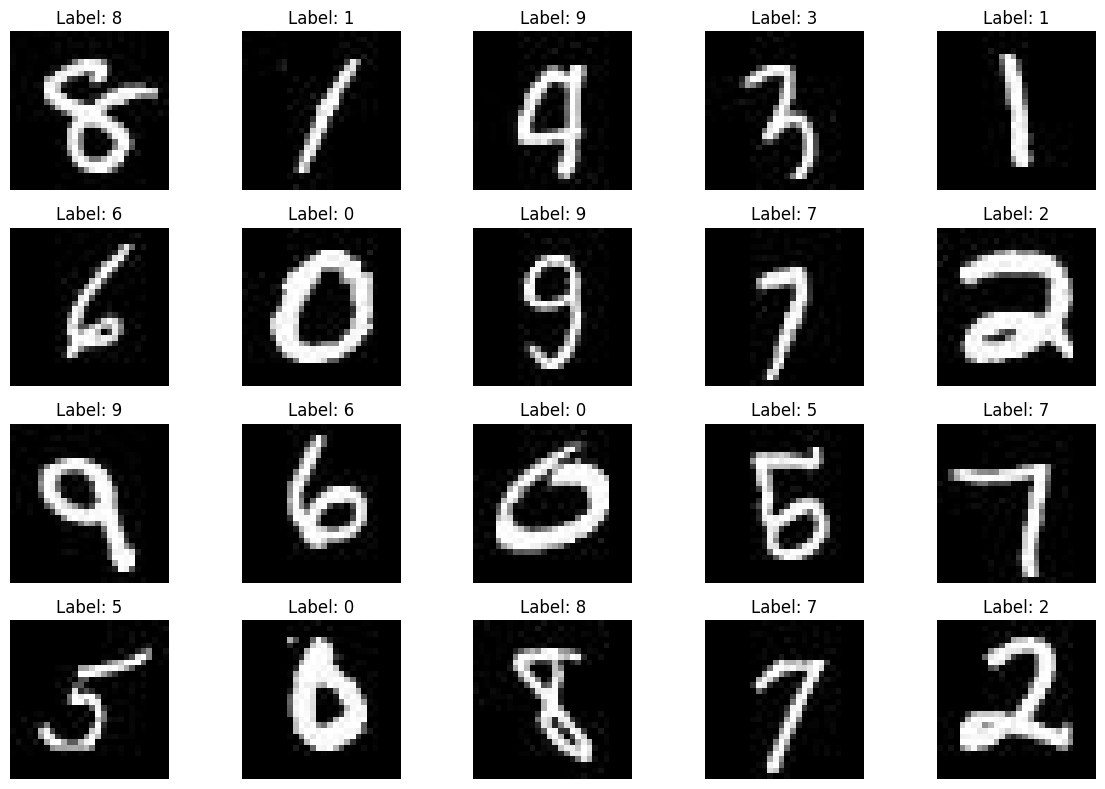

In [10]:
plt.figure(figsize=(12, 8))

indices = np.random.choice(
    len(X),
    20,
    replace=False
)

for i, index in enumerate(indices):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X[index],
        cmap="gray"
    )

    plt.title(
        f"Label: {y[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
X = X.astype(np.float32) / 255.0

print("X dtype:", X.dtype)
print("Minimum:", X.min())
print("Maximum:", X.max())

X dtype: float32
Minimum: 0.0
Maximum: 1.0


In [12]:
X = X.reshape(
    X.shape[0],
    784
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (24170, 784)
y Shape: (24170,)


In [13]:
import gc

gc.collect()

print("Garbage collection completed.")

Garbage collection completed.


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y)
)

print("Train indices:", len(train_idx))
print("Test indices :", len(test_idx))

Train indices: 19336
Test indices : 4834


In [15]:
X_train = np.take(
    X,
    train_idx,
    axis=0
)

X_test = np.take(
    X,
    test_idx,
    axis=0
)

y_train = y[train_idx]
y_test = y[test_idx]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (19336, 784)
X_test : (4834, 784)
y_train: (19336,)
y_test : (4834,)


In [16]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining classes:")
print(np.unique(y_train))

print("\nTesting classes:")
print(np.unique(y_test))

X_train: (19336, 784)
X_test : (4834, 784)
y_train: (19336,)
y_test : (4834,)

Training classes:
[0 1 2 3 4 5 6 7 8 9]

Testing classes:
[0 1 2 3 4 5 6 7 8 9]


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance",
    n_jobs=1
)

print("Training KNN...")

knn_model.fit(
    X_train,
    y_train
)

print("KNN training completed!")

Training KNN...
KNN training completed!


In [18]:
print("Model:", knn_model)
print("Classes:", knn_model.classes_)
print("Number of features:", knn_model.n_features_in_)

Model: KNeighborsClassifier(n_jobs=1, n_neighbors=3, weights='distance')
Classes: [0 1 2 3 4 5 6 7 8 9]
Number of features: 784


In [19]:
from sklearn.metrics import accuracy_score

print("Predicting test data...")

y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"KNN Accuracy: {accuracy:.4f}")
print(f"KNN Accuracy: {accuracy * 100:.2f}%")

Predicting test data...
KNN Accuracy: 0.9652
KNN Accuracy: 96.52%


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       483
           1       0.95      0.99      0.97       483
           2       0.99      0.94      0.96       483
           3       0.96      0.96      0.96       484
           4       0.98      0.97      0.97       484
           5       0.96      0.95      0.96       483
           6       0.96      0.99      0.97       484
           7       0.95      0.98      0.96       483
           8       0.98      0.93      0.95       483
           9       0.94      0.96      0.95       484

    accuracy                           0.97      4834
   macro avg       0.97      0.97      0.97      4834
weighted avg       0.97      0.97      0.97      4834



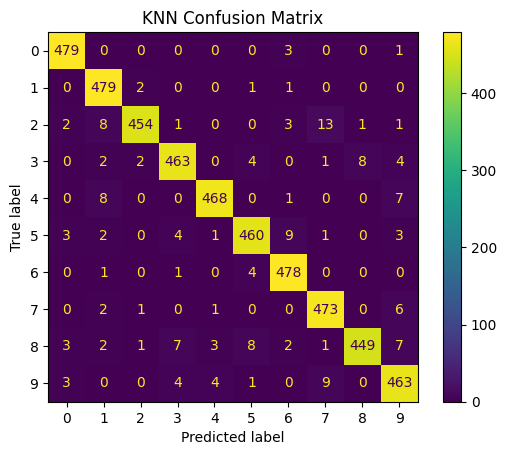

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("KNN Confusion Matrix")
plt.show()

In [22]:
import joblib

joblib.dump(
    knn_model,
    "trained_model.pkl"
)

print("trained_model.pkl saved successfully!")

trained_model.pkl saved successfully!


In [23]:
loaded_model = joblib.load(
    "trained_model.pkl"
)

print("Model loaded successfully!")
print("Classes:", loaded_model.classes_)
print("Features:", loaded_model.n_features_in_)

Model loaded successfully!
Classes: [0 1 2 3 4 5 6 7 8 9]
Features: 784
